# Panorama competitivo de UNAB

Dónde compite UNAB en pregrado, contra quién, y con qué resultado.

El notebook [01](01_exploracion_validacion.ipynb) recorre la base y valida que los cálculos del
sitio sean correctos. Este da por sentado eso y responde la pregunta de gestión: **¿en qué
mercados está parada UNAB y qué posición tiene en cada uno?**

El motor vive en [`analisis/mercados.py`](../analisis/mercados.py) y es el mismo que usa el
notebook 01. Una sola implementación: cuando un criterio cambia, cambia en un lugar.

**Configuración por defecto:** universidades, pregrado, matrícula de primer año, mercado definido
por área genérica + región + jornada, umbral de liderazgo compartido 5%.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

RAIZ = next(p for p in [Path('.'), Path('..')] if (p / 'analisis').exists())
sys.path.insert(0, str(RAIZ.resolve()))

from analisis.mercados import (cargar_base, construir_mercados, situacion, resumen_foco,
                               PALETA, ESTILO, UNAB)

plt.rcParams.update(ESTILO)
pd.set_option('display.width', 170)
pd.set_option('display.max_columns', 40)

df = cargar_base()
mk = construir_mercados(df, foco=UNAB)      # defaults del sitio
f  = situacion(mk, UNAB)

print(f'Base   : {len(df):,} carreras')
print(f'Mercados donde UNAB compite: {len(f)}')

Base   : 16,089 carreras
Mercados donde UNAB compite: 128


## 1. Dónde está parada

Cuatro situaciones, y conviene no confundirlas. Ser la única oferente de un mercado no es liderar,
y ganar por tres alumnos tampoco.

In [2]:
resumen_foco(mk, UNAB)

,mercados,%
situación,,
Lidera sola,25,19.5
Liderazgo compartido,3,2.3
Sin competencia,15,11.7
No lidera,85,66.4


25 liderazgos limpios sobre 128 mercados. En dos tercios de donde compite, UNAB no lidera.

### El gráfico que junta las dos preguntas

Cómo compite y dónde, en una sola imagen: cada punto es un mercado, el eje horizontal es su tamaño
y el vertical la participación de UNAB.

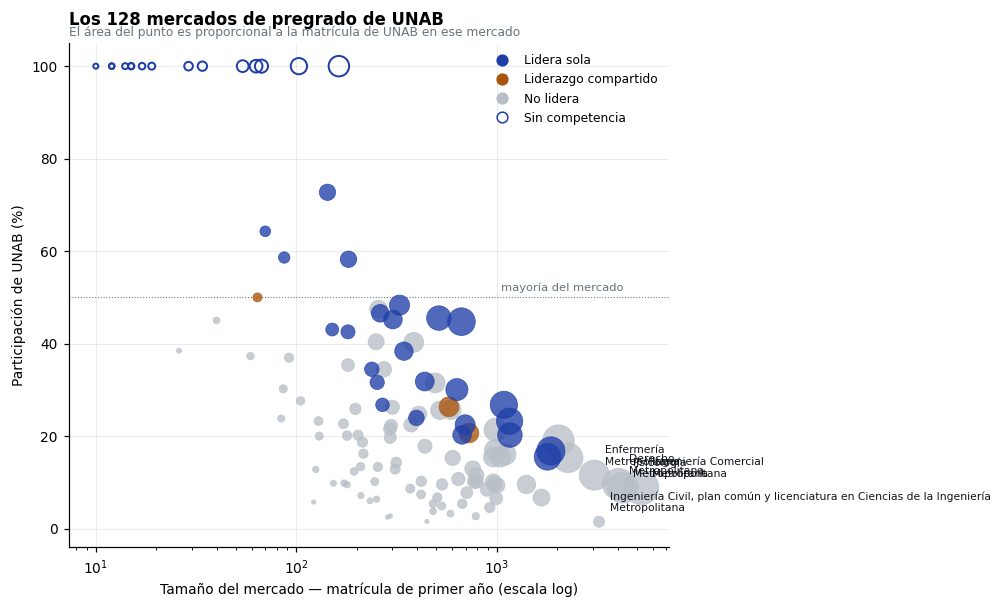

In [3]:
COLOR = {
    'Lidera sola':          PALETA['foco'],
    'Liderazgo compartido': PALETA['lider'],
    'Sin competencia':      PALETA['foco'],
    'No lidera':            PALETA['gris'],
}

fig, ax = plt.subplots(figsize=(9, 5.6))

for sit in ['No lidera', 'Sin competencia', 'Liderazgo compartido', 'Lidera sola']:
    s = f[f.situacion == sit]
    hueco = sit == 'Sin competencia'
    ax.scatter(s.total_mercado, s.share, s=s.val * 1.1,
               facecolors='none' if hueco else COLOR[sit],
               edgecolors=COLOR[sit], linewidths=1.3 if hueco else .5,
               alpha=1 if hueco else .78, zorder=3 if sit != 'No lidera' else 2)

ax.set_xscale('log')
ax.axhline(50, color=PALETA['suave'], lw=.7, ls=':', zorder=1)
ax.text(1.05e3, 51.5, 'mayoría del mercado', fontsize=7.5, color=PALETA['suave'])

# anotar los mercados que importan: los más grandes donde no lidera
for _, r in f.nlargest(5, 'total_mercado').iterrows():
    ax.annotate(f'{r.area_generica}\n{r.geo}', (r.total_mercado, r.share),
                textcoords='offset points', xytext=(7, 7), fontsize=7,
                color=PALETA['tinta'], ha='left')

ax.set_xlabel('Tamaño del mercado — matrícula de primer año (escala log)')
ax.set_ylabel('Participación de UNAB (%)')
ax.set_ylim(-4, 105)
ax.set_title('Los 128 mercados de pregrado de UNAB', loc='left', fontweight='bold', pad=12)
ax.text(0, 1.015, 'El área del punto es proporcional a la matrícula de UNAB en ese mercado',
        transform=ax.transAxes, fontsize=8, color=PALETA['suave'])

leyenda = [Line2D([0], [0], marker='o', color='none', markerfacecolor=COLOR[s],
                  markeredgecolor=COLOR[s], markersize=7, label=s)
           for s in ['Lidera sola', 'Liderazgo compartido', 'No lidera']]
leyenda.append(Line2D([0], [0], marker='o', color='none', markerfacecolor='none',
                      markeredgecolor=PALETA['foco'], markersize=7, label='Sin competencia'))
ax.legend(handles=leyenda, loc='upper right', fontsize=8)

plt.tight_layout(); plt.show()

La forma de la nube es la tesis: **una diagonal descendente.** Mientras más grande el mercado,
menor la participación de UNAB. Arriba a la izquierda, los feudos —mercados chicos donde domina o
está sola—. Abajo a la derecha, los mercados grandes de la Región Metropolitana donde es una más
entre doce.

No hay un solo punto grande arriba a la derecha. UNAB no lidera ningún mercado masivo.

In [4]:
grandes = f.nlargest(10, 'total_mercado')[
    ['area_generica', 'geo', 'jornada', 'val', 'total_mercado', 'share', 'pos', 'n_inst', 'situacion']]
grandes.columns = ['carrera', 'territorio', 'jornada', 'UNAB', 'mercado', 'share_%', 'pos', 'inst', 'situación']
grandes.round(1).reset_index(drop=True)

,carrera,territorio,jornada,UNAB,mercado,share_%,pos,inst,situación
0,Ingeniería Comercial,Metropolitana,Diurna,469.0,5265.0,8.9,3,22,No lidera
1,Psicología,Metropolitana,Diurna,376.0,4243.0,8.9,2,25,No lidera
2,Derecho,Metropolitana,Diurna,388.0,4039.0,9.6,2,24,No lidera
3,"Ingeniería Civil, plan común y licenciatura en...",Metropolitana,Diurna,48.0,3233.0,1.5,9,10,No lidera
4,Enfermería,Metropolitana,Diurna,354.0,3065.0,11.5,2,19,No lidera
5,Kinesiología,Metropolitana,Diurna,347.0,2266.0,15.3,2,20,No lidera
6,Medicina Veterinaria,Metropolitana,Diurna,386.0,2029.0,19.0,2,9,No lidera
7,Ingeniería Civil Industrial,Metropolitana,Diurna,312.0,1859.0,16.8,1,17,Lidera sola
8,Ingeniería Civil en Computación e Informática,Metropolitana,Diurna,278.0,1791.0,15.5,1,14,Lidera sola
9,Arquitectura,Metropolitana,Diurna,112.0,1669.0,6.7,8,15,No lidera


Los diez mercados más grandes donde UNAB compite. En ninguno lidera.

In [5]:
feudos = f[f.situacion.isin(['Lidera sola', 'Liderazgo compartido'])].nlargest(10, 'share')[
    ['area_generica', 'geo', 'jornada', 'val', 'total_mercado', 'share', 'n_inst', 'situacion']]
feudos.columns = ['carrera', 'territorio', 'jornada', 'UNAB', 'mercado', 'share_%', 'inst', 'situación']
feudos.round(1).reset_index(drop=True)

,carrera,territorio,jornada,UNAB,mercado,share_%,inst,situación
0,Biología Marina y Ecología Marina,Metropolitana,Diurna,104.0,143.0,72.7,2,Lidera sola
1,Psicología,Valparaíso,Vespertina,45.0,70.0,64.3,2,Lidera sola
2,Administración de Empresas e Ing. Asociadas,Valparaíso,Diurna,51.0,87.0,58.6,2,Lidera sola
3,Administración Turística y Hotelera,Metropolitana,Diurna,106.0,182.0,58.2,3,Lidera sola
4,Administración de Empresas e Ing. Asociadas,Metropolitana,Vespertina,32.0,64.0,50.0,2,Liderazgo compartido
5,Odontología,Valparaíso,Diurna,158.0,327.0,48.3,3,Lidera sola
6,Química y Farmacia,Valparaíso,Diurna,122.0,262.0,46.6,3,Lidera sola
7,Medicina Veterinaria,Valparaíso,Diurna,234.0,514.0,45.5,4,Lidera sola
8,Ingeniería en Comercio Exterior,Metropolitana,Diurna,137.0,303.0,45.2,3,Lidera sola
9,Bachillerato y/o Licenciatura en Salud,Metropolitana,Diurna,298.0,666.0,44.7,3,Lidera sola


Y el otro extremo. Donde UNAB manda, el mercado es chico y hay dos o tres competidores.

**La lectura de gestión:** el volumen de UNAB no viene de ganar mercados, viene de estar en muchos.
Son estrategias distintas y conviene no confundirlas en un informe.

## 2. Por área de conocimiento

### Qué taxonomía usar

La base trae tres clasificaciones y no dan lo mismo para capitular el análisis.

In [6]:
u = df[(df.institucion == UNAB) & (df.nivel_global == 'Pregrado')]

comp = []
for col, nombre in [('area', 'SIES — Área del conocimiento'),
                    ('cine_area', 'CINE-F 2013 — Área'),
                    ('cine_subarea', 'CINE-F 2013 — Subárea')]:
    t = u.groupby(col).mat_total.sum()
    p = t / t.sum() * 100
    comp.append({
        'taxonomía': nombre,
        'categorías': len(t),
        'mayor_%': round(p.max(), 1),
        'categorías_bajo_3%': int((p < 3).sum()),
        'menor_alumnos': int(t.min()),
    })
pd.DataFrame(comp)

,taxonomía,categorías,mayor_%,categorías_bajo_3%,menor_alumnos
0,SIES — Área del conocimiento,10,32.4,2,56
1,CINE-F 2013 — Área,10,33.2,1,905
2,CINE-F 2013 — Subárea,22,32.4,14,2


**CINE-F 2013 área** es la que usa este análisis, por tres razones concretas:

- Separa **TIC de Ingeniería** (3.261 y 9.729 alumnos en UNAB). Son mercados distintos con
  competidores distintos; el SIES los mete juntos en "Tecnología".
- El SIES eleva **Derecho** a área propia con una sola área genérica adentro, mientras Ingeniería
  Comercial queda enterrada en "Administración y Comercio". CINE agrupa como corresponde.
- Deja **una sola categoría bajo el 3%**, contra dos del SIES. La Humanidades del SIES —una
  carrera, 56 alumnos— no da para un capítulo.

Súmese que es la clasificación que usa la CNA y que permite comparar afuera.

**Importante:** la taxonomía no cambia ningún número. Los mercados se arman por área genérica,
siempre. La taxonomía solo decide en qué capítulo cae cada mercado.

Lo que ninguna taxonomía arregla: Salud es un tercio de UNAB en las tres. Eso no es defecto de
clasificación, es la institución.

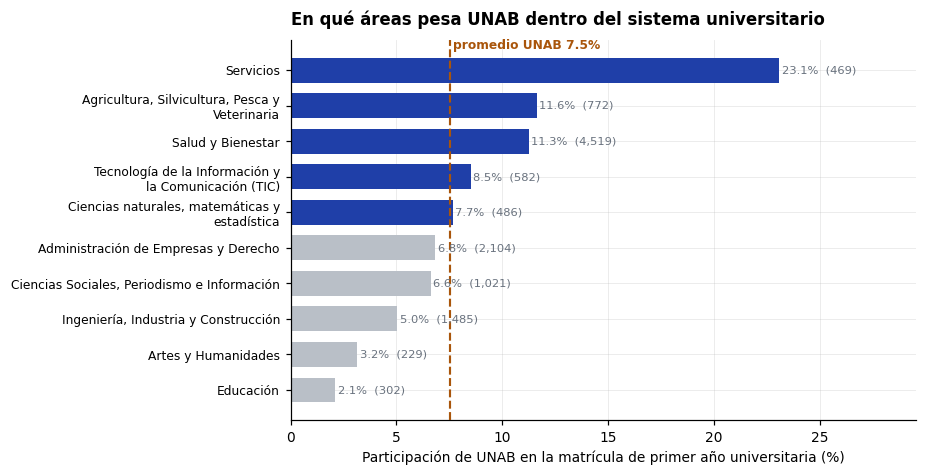

In [7]:
uni = df[(df.tipo_inst == 'Universidades') & (df.nivel_global == 'Pregrado')]
uni = uni[uni.mat1_total.notna() & (uni.mat1_total > 0)]

sis = uni.groupby('cine_area').mat1_total.sum()
una = uni[uni.institucion == UNAB].groupby('cine_area').mat1_total.sum()
ar = pd.DataFrame({'UNAB': una, 'sistema': sis}).dropna()
ar['share_%'] = ar.UNAB / ar.sistema * 100
ar = ar.sort_values('share_%', ascending=True)

fig, ax = plt.subplots(figsize=(8.5, 4.4))
prom = ar.UNAB.sum() / ar.sistema.sum() * 100
cols = [PALETA['foco'] if v >= prom else PALETA['gris'] for v in ar['share_%'].values]
ax.barh(range(len(ar)), ar['share_%'], color=cols, height=.7)
ax.axvline(prom, color=PALETA['lider'], lw=1.4, ls='--', zorder=3)
ax.text(prom + .15, len(ar) - .4, f'promedio UNAB {prom:.1f}%', color=PALETA['lider'],
        fontsize=8, fontweight='bold')
ax.set_yticks(range(len(ar)), [i.replace(' y ', ' y\n') if len(i) > 38 else i for i in ar.index],
              fontsize=8)
ax.set_xlabel('Participación de UNAB en la matrícula de primer año universitaria (%)')
ax.set_title('En qué áreas pesa UNAB dentro del sistema universitario',
             loc='left', fontweight='bold', pad=10)
for i, (v, n) in enumerate(zip(ar['share_%'], ar.UNAB)):
    ax.text(v + .12, i, f'{v:.1f}%  ({int(n):,})', va='center', fontsize=7.5,
            color=PALETA['suave'])
ax.set_xlim(0, ar['share_%'].max() * 1.28)
plt.tight_layout(); plt.show()

Acá aparece algo que el promedio esconde. UNAB no es una universidad uniformemente grande: es muy
grande en unas áreas y marginal en otras. La barra de referencia es su propio promedio, no el del
sistema.

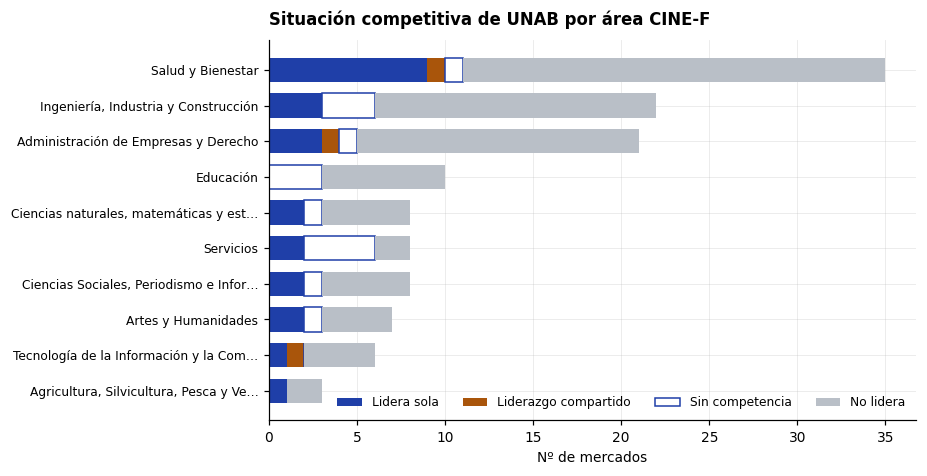

In [8]:
sit_area = pd.crosstab(f.cine_area, f.situacion)
orden_cols = [c for c in ['Lidera sola', 'Liderazgo compartido', 'Sin competencia', 'No lidera']
              if c in sit_area.columns]
sit_area = sit_area[orden_cols]
sit_area['total'] = sit_area.sum(axis=1)
sit_area = sit_area.sort_values('total', ascending=True)

fig, ax = plt.subplots(figsize=(8.5, 4.4))
izq = np.zeros(len(sit_area))
estilos = {'Lidera sola': (PALETA['foco'], PALETA['foco']),
           'Liderazgo compartido': (PALETA['lider'], PALETA['lider']),
           'Sin competencia': ('white', PALETA['foco']),
           'No lidera': (PALETA['gris'], PALETA['gris'])}
for c in orden_cols:
    fc, ec = estilos[c]
    ax.barh(range(len(sit_area)), sit_area[c], left=izq, color=fc, edgecolor=ec,
            linewidth=1 if fc == 'white' else 0, height=.68, label=c)
    izq += sit_area[c].values

ax.set_yticks(range(len(sit_area)),
              [i if len(i) < 40 else i[:37] + '…' for i in sit_area.index], fontsize=8)
ax.set_xlabel('Nº de mercados')
ax.set_title('Situación competitiva de UNAB por área CINE-F', loc='left', fontweight='bold', pad=10)
ax.legend(fontsize=8, ncol=4, loc='lower right')
plt.tight_layout(); plt.show()

In [9]:
tab = pd.crosstab(f.cine_area, f.situacion, margins=True, margins_name='TOTAL')
tab = tab[[c for c in ['Lidera sola', 'Liderazgo compartido', 'Sin competencia', 'No lidera', 'TOTAL']
           if c in tab.columns]]
tab

situacion,Lidera sola,Liderazgo compartido,Sin competencia,No lidera,TOTAL
cine_area,,,,,
Administración de Empresas y Derecho,3,1,1,16,21
"Agricultura, Silvicultura, Pesca y Veterinaria",1,0,0,2,3
Artes y Humanidades,2,0,1,4,7
"Ciencias Sociales, Periodismo e Información",2,0,1,5,8
"Ciencias naturales, matemáticas y estadística",2,0,1,5,8
Educación,0,0,3,7,10
"Ingeniería, Industria y Construcción",3,0,3,16,22
Salud y Bienestar,9,1,1,24,35
Servicios,2,0,4,2,8


## 3. Por territorio

UNAB tiene sedes en tres regiones. La competencia no es la misma en cada una.

In [10]:
reg = f.groupby('geo').agg(mercados=('area_generica', 'count'), unab=('val', 'sum'),
                           mercado=('total_mercado', 'sum'))
reg['share_%'] = (reg.unab / reg.mercado * 100).round(1)
reg['lidera']  = f[f.situacion.isin(['Lidera sola', 'Liderazgo compartido'])].groupby('geo').size()
reg['sin_competencia'] = f[f.situacion == 'Sin competencia'].groupby('geo').size()
reg = reg.fillna(0).astype({'lidera': int, 'sin_competencia': int})
reg.sort_values('unab', ascending=False)

,mercados,unab,mercado,share_%,lidera,sin_competencia
geo,,,,,,
Metropolitana,62,6889.0,53271.0,12.9,17,4
Valparaíso,35,3023.0,11487.0,26.3,10,4
Biobío,31,2057.0,11275.0,18.2,1,7


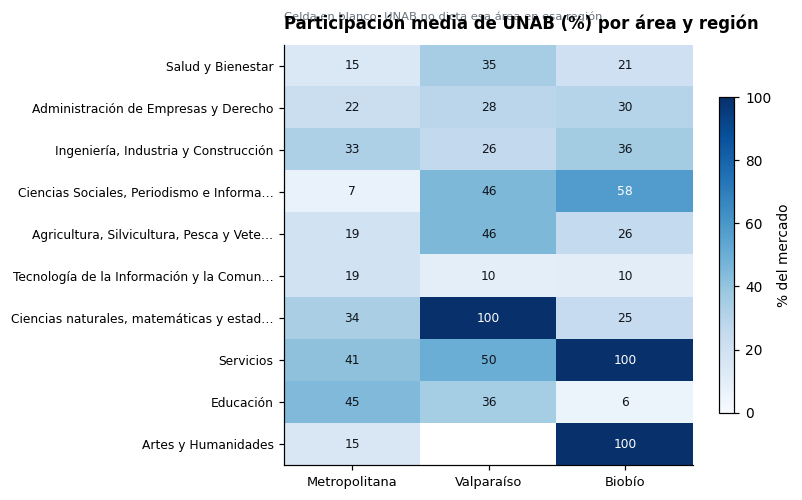

In [11]:
piv = f.pivot_table(index='cine_area', columns='geo', values='share', aggfunc='mean')
piv = piv.reindex(f.groupby('cine_area').val.sum().sort_values(ascending=False).index)
piv = piv[f.groupby('geo').val.sum().sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(7.4, 4.6))
m = np.ma.masked_invalid(piv.values)
im = ax.imshow(m, cmap='Blues', vmin=0, vmax=100, aspect='auto')
ax.set_xticks(range(piv.shape[1]), piv.columns, fontsize=8.5)
ax.set_yticks(range(piv.shape[0]),
              [i if len(i) < 42 else i[:39] + '…' for i in piv.index], fontsize=8)
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        v = piv.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.0f}', ha='center', va='center', fontsize=8,
                    color='white' if v > 55 else PALETA['tinta'])
ax.set_title('Participación media de UNAB (%) por área y región',
             loc='left', fontweight='bold', pad=10)
ax.text(0, 1.06, 'Celda en blanco: UNAB no dicta esa área en esa región',
        transform=ax.transAxes, fontsize=7.5, color=PALETA['suave'])
ax.grid(False)
plt.colorbar(im, ax=ax, shrink=.75, label='% del mercado')
plt.tight_layout(); plt.show()

El patrón regional: en la Región Metropolitana UNAB compite contra todos y sus participaciones son
bajas; en Valparaíso y Biobío la competencia es más delgada y las cifras suben. La misma
institución mide distinto según dónde se pare, y no porque sea mejor en provincia.

## 4. Por jornada

In [12]:
jor = f.groupby('jornada').agg(mercados=('area_generica', 'count'), unab=('val', 'sum'),
                               mercado=('total_mercado', 'sum'))
jor['share_%'] = (jor.unab / jor.mercado * 100).round(1)
jor['inst_promedio'] = f.groupby('jornada').n_inst.mean().round(1)
jor.sort_values('unab', ascending=False)

,mercados,unab,mercado,share_%,inst_promedio
jornada,,,,,
Diurna,112,11402.0,73087.0,15.6,6.6
Vespertina,13,397.0,2225.0,17.8,3.7
A Distancia,3,170.0,721.0,23.6,3.7


Una advertencia sobre esta tabla: el mercado por defecto **exige misma jornada**, así que compara
diurno contra diurno. Si un postulante en realidad elige entre diurno y vespertino, esta partición
sobreestima la participación de UNAB en ambos. Es un supuesto declarado, no un hecho: se apaga con
el control de jornada del sitio o con `match_jornada=False`.

In [13]:
sin_jornada = construir_mercados(df, foco=UNAB, match_jornada=False)
r1 = resumen_foco(mk, UNAB)['mercados']
r2 = resumen_foco(sin_jornada, UNAB)['mercados']
pd.DataFrame({'exige misma jornada': r1, 'jornadas juntas': r2})

,exige misma jornada,jornadas juntas
situación,,
Lidera sola,25,26
Liderazgo compartido,3,1
Sin competencia,15,11
No lidera,85,75


Fundir las jornadas reduce los mercados y cambia el conteo de liderazgos. Ninguna de las dos
lecturas es la verdadera: depende de si el postulante considera ambas jornadas, y eso la base no
lo dice.

## 5. Qué queda anotado

**El hallazgo central:** la nube del primer gráfico baja de izquierda a derecha. UNAB no lidera
ningún mercado masivo. Sus 25 liderazgos limpios están en mercados chicos, y sus carreras más
grandes —Ingeniería Comercial, Derecho, Psicología en la Región Metropolitana— la tienen bajo el
10%. El volumen de UNAB viene de estar en muchos mercados, no de ganar en ellos.

**Lo que este notebook no puede decir:**

- Si esa posición mejoró o empeoró. La base es un corte de 2025 sin serie histórica.
- Si la participación baja se explica por precio, ubicación, selectividad o marca. Nada de eso
  está en esta base.
- Los planes de continuidad quedan fuera de todo lo que use primer año: el SIES no reporta ese
  dato para ellos, y son 33.298 alumnos solo en online.

**Supuestos que cambian el resultado y hay que declarar:**

| Supuesto | Default | Efecto |
|---|---|---|
| Ámbito geográfico | región | Psicología pasa de 54,7% (comuna) a 8,9% (región) |
| Misma jornada | sí | fundir jornadas cambia el conteo de liderazgos |
| Umbral de liderazgo compartido | 5% | con 10%, 12 liderazgos pasan a compartidos |
| Universo | universidades | incluir IP y CFT diluye toda participación |

**Siguiente paso:** los notebooks por área CINE-F, generados desde una plantilla que importe este
mismo motor.